# Audio Feature-Aware Recommender System
## Spotify MPD — Content-Based Filtering with Audio Features

This notebook implements a content-based recommender system that uses audio features
mapped onto the MPD track catalog. Before running this notebook, the following
scripts must have been executed in order:

| Script | Output | Description |
|---|---|---|
| `src/ingest.py` | `processed/track_meta.parquet` | Extracts deduplicated track catalog from raw MPD JSON slices |
| `src/map_datasets.py` | `processed/track_audio_features.parquet` | Downloads the Spotify Audio Features dataset from Kaggle and maps it onto `track_meta.parquet` by matching on normalized artist name + track name |
| `src/filter_tracks_with_data.py` | `processed/filtered_tracks_audio.parquet`, `processed/filtered_playlists_audio.parquet` | Removes unmatched tracks and rebuilds playlist/track parquets keeping only playlists with at least 20 matched tracks |

### Dataset after preprocessing

- **539,913** out of 2,262,292 unique tracks matched with audio features (23.9%)
- **42.7%** of track entries retained after filtering
- **~400k+ playlists** with at least 20 matched tracks remaining
- Audio features available: `acousticness`, `danceability`, `duration_ms`, `energy`,
  `instrumentalness`, `key`, `liveness`, `loudness`, `mode`, `speechiness`,
  `tempo`, `time_signature`, `valence`, `popularity`

---

## Approaches

### 1. Content-Based Filtering (implemented below)
Given a seed playlist, compute the mean audio feature vector across all seed tracks.
Recommend the tracks whose feature vectors are closest to this mean (cosine or
Euclidean distance), excluding tracks already in the playlist.

**Strengths:**
- Fully interpretable — recommendations are acoustically similar to the seed
- No training required
- Works well for mood/energy-coherent playlists (workout, chill, christmas)
- Cold-start friendly — works even for brand new playlists

**Weaknesses:**
- Ignores co-occurrence signal — a track can be acoustically similar but
  never appear in the same playlists as the seed tracks
- Tends to over-recommend tracks from the same artist/album (acoustic near-duplicates)
- Feature coverage is limited to the 313k matched tracks

---

### 2. Feature-Augmented Collaborative Filtering (future work)
Combine audio feature similarity with track co-occurrence signal. For each candidate
track, compute a hybrid score:
```
score = α × co_occurrence_score + (1 - α) × audio_similarity_score
```
Co-occurrence is computed from how often a track appears alongside seed tracks
across all training playlists. Audio similarity is cosine distance in feature space.
The weight α controls the tradeoff between collaborative and content signal.

**Why this would be better:** It combines the best of both worlds — tracks that are
both acoustically fitting AND known to co-occur with similar playlists. This is
similar to the approach used by the 4th-place ACM challenge team (cocoplaya), who
combined matrix factorization with audio-based content filtering.

---

### 3. Feature-Augmented GRU/Transformer (future work)
Extend the sequential models from the Modeling notebook by concatenating audio
features into the track embedding at each sequence position:
```
input_t = concat(embedding(track_id_t), audio_features_t)
```
The model then learns to use both the learned co-occurrence representation and
the raw acoustic properties when predicting the next track.

**Why this would be better:** The GRU/Transformer already learned strong sequential
patterns from co-occurrence. Adding audio features gives the model explicit musical
content information — it can learn that a high-energy playlist should continue with
high-energy tracks, rather than inferring this indirectly from co-occurrence alone.
The main constraint is that only 42.7% of track entries have audio features, so
unmatched tracks would need a zero or mean feature vector as a fallback.

---
## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../processed')
OUT       = Path('outputs')
OUT.mkdir(exist_ok=True)

SEED_RATIO  = 0.8
K_VALUES    = [1, 5, 10, 20]
MAX_EVAL    = 5000
RANDOM_SEED = 42

---
## 1. Load Data

In [2]:
audio    = pd.read_parquet(PROCESSED / 'track_audio_features.parquet')
tracks   = pd.read_parquet(PROCESSED / 'filtered_tracks_audio.parquet')
playlists = pd.read_parquet(PROCESSED / 'filtered_playlists_audio.parquet')

print(f'Playlists    : {len(playlists):,}')
print(f'Track entries: {len(tracks):,}')
print(f'Unique tracks: {tracks["track_uri"].nunique():,}')

# Identify audio feature columns
meta_cols = {'track_uri', 'track_name', 'artist_uri', 'artist_name',
             'album_uri', 'album_name', 'track_dur_ms'}
feature_cols = [c for c in audio.columns if c not in meta_cols and audio[c].dtype in ['float64', 'int64', 'float32']]
print(f'\nAudio feature columns: {feature_cols}')

Playlists    : 523,269
Track entries: 23,503,639
Unique tracks: 465,984

Audio feature columns: ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity']


---
## 2. Audio Feature Analysis

Before building the recommender, let's understand the distribution of audio features
across the matched tracks.

In [3]:
track_features = audio[audio['track_uri'].isin(tracks['track_uri'].unique())].copy()
track_features = track_features[['track_uri'] + feature_cols].dropna()

print(f'Tracks with complete audio features: {len(track_features):,}')
print(f'\nFeature statistics:')
print(track_features[feature_cols].describe().round(3))

Tracks with complete audio features: 465,984

Feature statistics:
       acousticness  danceability  duration_ms      energy  instrumentalness  \
count    465984.000    465984.000   465984.000  465984.000        465984.000   
mean          0.300         0.594   211806.259       0.598             0.182   
std           0.318         0.166    80986.946       0.233             0.333   
min           0.000         0.000    10250.000       0.000             0.000   
25%           0.031         0.481   174857.000       0.447             0.000   
50%           0.162         0.608   206629.000       0.631             0.000   
75%           0.525         0.717   241875.000       0.781             0.122   
max           0.996         0.986  5610020.000       1.000             0.999   

              key    liveness    loudness        mode  speechiness  \
count  465984.000  465984.000  465984.000  465984.000   465984.000   
mean        5.241       0.178      -8.617       0.609        0.101   
std

### Deduplication

The Kaggle audio features dataset may contain duplicate entries for the same track
(same name, same artist) introduced by different album releases, remasters, or
regional variants. We remove these by keeping only the first occurrence per
`(artist_name, track_name, tempo, track_dur_ms)` combination.

We deliberately include `tempo` and `track_dur_ms` in the deduplication key so that
two genuinely different songs that happen to share a name and artist are preserved —
for example a studio version and a live version of the same song will have different
durations and tempos and will both be kept.

In [10]:
before = len(track_features)

track_features = track_features.copy()

# Join track name and artist name from audio for dedup key
meta_for_dedup = audio[['track_uri', 'track_name', 'artist_name']].drop_duplicates('track_uri')
track_features = track_features.merge(meta_for_dedup, on='track_uri', how='left')

# Round tempo and duration to avoid floating point mismatches
track_features['_tempo_r'] = track_features['tempo'].round(0)
track_features['_dur_r']   = track_features['track_dur_ms'].round(-3) if 'track_dur_ms' in track_features.columns else 0

dedup_key = ['artist_name', 'track_name', '_tempo_r', '_dur_r']
track_features = track_features.drop_duplicates(subset=dedup_key, keep='first')

# Drop helper columns
track_features = track_features.drop(columns=['_tempo_r', '_dur_r', 'track_name', 'artist_name'],
                                      errors='ignore')

after = len(track_features)
print(f'Tracks before dedup: {before:,}')
print(f'Tracks after dedup : {after:,}')
print(f'Duplicates removed : {before - after:,}')

Tracks before dedup: 465,984
Tracks after dedup : 448,581
Duplicates removed : 17,403


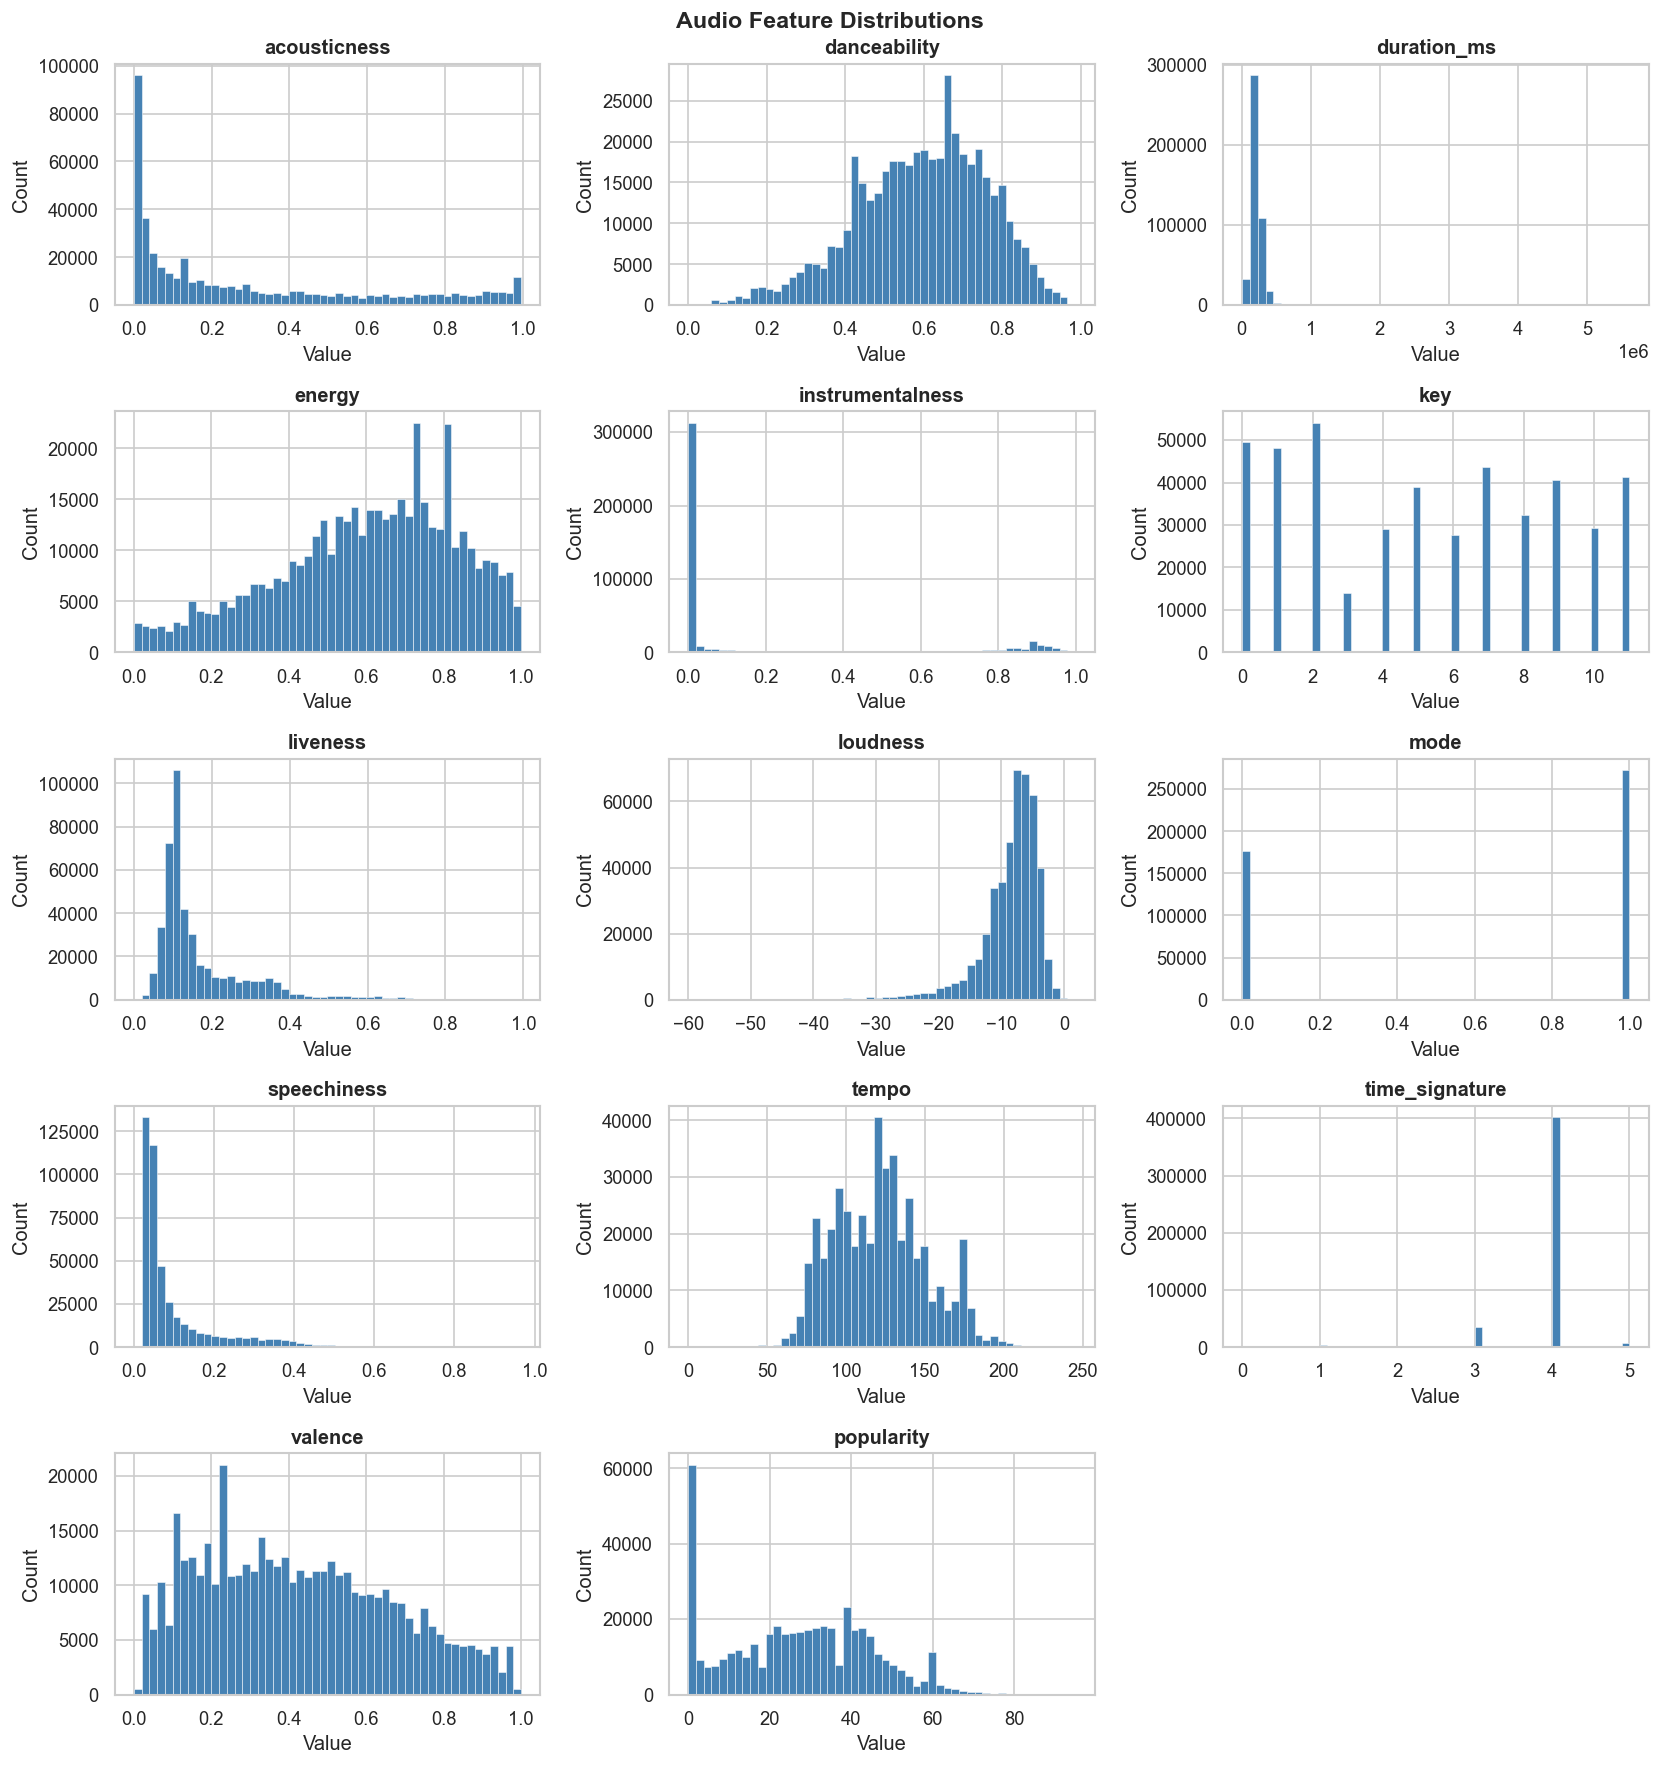

In [11]:
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, feature_cols):
    ax.hist(track_features[col].dropna(), bins=50, color='steelblue',
            edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

for ax in axes_flat[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Audio Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'audio_feature_distributions.png', bbox_inches='tight')
plt.show()

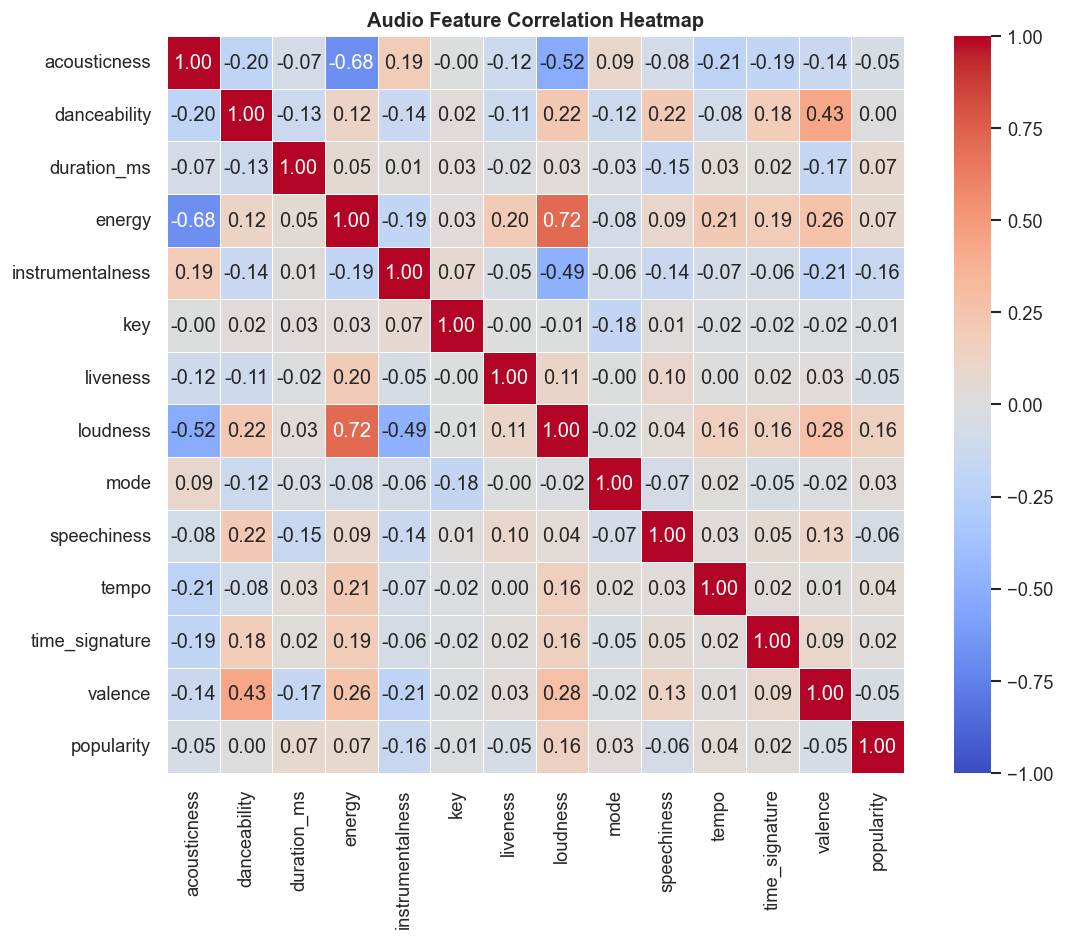

In [12]:
# Correlation between audio features
corr = track_features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Audio Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'audio_feature_correlation.png', bbox_inches='tight')
plt.show()

## Feature Selection for Content-Based Modeling

Before building the feature matrix, several audio features require preprocessing
or removal based on their distributions and correlations.

### Dropped Features

| Feature | Reason |
|---|---|
| `key` | Categorical (0–11 representing musical keys C, C#, D…). Treating it as continuous in cosine similarity is meaningless — key 11 is not acoustically "more" than key 0. Would require one-hot encoding to use correctly. |
| `time_signature` | Near-zero variance — almost all tracks are in 4/4 time. Adds no discriminative signal. |
| `duration_ms` | Extreme outliers (values up to 5×10⁶ ms) that distort distance calculations even after scaling. Duration is also not a meaningful acoustic similarity feature — a 3-minute pop song and a 3-minute jazz track are not acoustically similar just because they share a length. |

### Clipped Features

`loudness`, `tempo`, and `popularity` are clipped to their 1st–99th percentile
range before scaling to remove extreme outliers that would otherwise distort the
StandardScaler normalization.

### Redundant but Kept Features

`energy` and `loudness` are strongly correlated (r=0.72), as are `acousticness`
and `energy` (r=-0.68). Both pairs are kept since removing them would require
a more principled dimensionality reduction step (e.g. PCA), and the StandardScaler
normalization already limits the influence of any single feature.

### Final Feature Set

The following features are used for cosine similarity:
`acousticness`, `danceability`, `energy`, `instrumentalness`, `liveness`,
`loudness`, `mode`, `speechiness`, `tempo`, `valence`, `popularity`

In [13]:
# Drop low-signal or categorical features not suitable for cosine similarity
drop_cols = ['key', 'time_signature', 'duration_ms']

# Cap loudness and tempo outliers at 1st-99th percentile
for col in ['loudness', 'tempo', 'popularity']:
    lo = track_features[col].quantile(0.01)
    hi = track_features[col].quantile(0.99)
    track_features[col] = track_features[col].clip(lo, hi)

feature_cols_model = [c for c in feature_cols if c not in drop_cols]

---
## 3. Content-Based Recommender

Given a playlist seed, compute the mean audio feature vector of the seed tracks.
Recommend the tracks with the highest cosine similarity to this mean vector,
excluding tracks already in the playlist.

### 3.1 Build feature matrix

In [14]:
# Build a track_uri -> feature vector lookup
feature_matrix = track_features.set_index('track_uri')[feature_cols].copy()

# Normalize features to zero mean and unit variance
scaler = StandardScaler()
feature_matrix_scaled = pd.DataFrame(
    scaler.fit_transform(feature_matrix),
    index=feature_matrix.index,
    columns=feature_cols
)

print(f'Feature matrix shape: {feature_matrix_scaled.shape}')
print(f'Tracks with features: {len(feature_matrix_scaled):,}')

Feature matrix shape: (448581, 14)
Tracks with features: 448,581


### 3.2 Recommender function

In [15]:
feature_array = feature_matrix_scaled.values
feature_index = feature_matrix_scaled.index.tolist()
uri_to_pos    = {uri: i for i, uri in enumerate(feature_index)}

def recommend_content(seed_uris: list[str], k: int = 10) -> list[dict]:
    """
    Given a list of seed track URIs, return the top-k most similar tracks
    by cosine similarity to the mean seed feature vector.
    """
    # Get feature vectors for seed tracks that have features
    seed_positions = [uri_to_pos[u] for u in seed_uris if u in uri_to_pos]
    if not seed_positions:
        return []

    # Mean feature vector of seed
    seed_vec = feature_array[seed_positions].mean(axis=0, keepdims=True)

    # Cosine similarity against all tracks
    sims = cosine_similarity(seed_vec, feature_array)[0]

    # Exclude seed tracks
    seen = set(seed_uris)
    ranked = sorted(
        [(feature_index[i], sims[i]) for i in range(len(feature_index))
         if feature_index[i] not in seen],
        key=lambda x: x[1], reverse=True
    )

    # Enrich with track metadata
    meta = audio.set_index('track_uri')[['track_name', 'artist_name']]
    recs = []
    for uri, score in ranked[:k]:
        row = meta.loc[uri] if uri in meta.index else pd.Series({'track_name': '?', 'artist_name': '?'})
        recs.append({
            'track_uri':   uri,
            'track_name':  row['track_name'],
            'artist_name': row['artist_name'],
            'similarity':  round(score, 4),
        })
    return recs

print('Recommender ready.')

Recommender ready.


### 3.3 Demo — single playlist

In [16]:
sample_pid = playlists.sample(1, random_state=RANDOM_SEED)['pid'].iloc[0]
pl_tracks  = (
    tracks[tracks['pid'] == sample_pid]
    .sort_values('pos')['track_uri']
    .tolist()
)
sp   = max(1, int(len(pl_tracks) * SEED_RATIO))
seed = pl_tracks[:sp]

recs = recommend_content(seed, k=10)

# Show seed audio profile
seed_vecs = [uri_to_pos[u] for u in seed if u in uri_to_pos]
seed_profile = pd.Series(
    scaler.inverse_transform(feature_array[seed_vecs].mean(axis=0, keepdims=True))[0],
    index=feature_cols
).round(3)

print(f'Playlist pid   : {sample_pid}')
print(f'Seed tracks    : {len(seed)} (of {len(pl_tracks)} total)')
print(f'\nSeed audio profile (mean):')
print(seed_profile.to_string())
print(f'\nTop-10 recommendations:')
for i, r in enumerate(recs, 1):
    print(f'  {i:2d}. {r["track_name"][:35]:35s}  –  {r["artist_name"]:<25s}  (sim={r["similarity"]})')

Playlist pid   : 230090
Seed tracks    : 25 (of 32 total)

Seed audio profile (mean):
acousticness             0.282
danceability             0.598
duration_ms         218463.000
energy                   0.603
instrumentalness         0.198
key                      5.880
liveness                 0.177
loudness                -8.394
mode                     0.600
speechiness              0.099
tempo                  114.091
time_signature           3.960
valence                  0.454
popularity              22.120

Top-10 recommendations:
   1. Ela Ela (Radio Edit)                 –  Bobi                       (sim=0.8192)
   2. The Legend Of Wooley Swamp           –  The Charlie Daniels Band   (sim=0.8144)
   3. Phony                                –  K-Rino                     (sim=0.8106)
   4. Phony                                –  BabyFace Gunna             (sim=0.8106)
   5. Phony (feat. Burn One)               –  Dirty                      (sim=0.8106)
   6. Phony              

---
## 4. Evaluation

For each test playlist:
- Seed = first 80% of tracks
- Holdout = remaining 20%
- Recommend top-K by audio similarity, compare with holdout

Metrics: Precision@K and Recall@K

In [18]:
rng = np.random.default_rng(RANDOM_SEED)
all_pids = playlists['pid'].tolist()
if len(all_pids) > MAX_EVAL:
    eval_pids = list(rng.choice(all_pids, MAX_EVAL, replace=False))
else:
    eval_pids = all_pids

metrics = {f'Prec@{k}': [] for k in K_VALUES}
metrics.update({f'Recall@{k}': [] for k in K_VALUES})

print_every = max(1, len(eval_pids) // 10)

for i, pid in enumerate(eval_pids):
    pl = (
        tracks[tracks['pid'] == pid]
        .sort_values('pos')['track_uri']
        .tolist()
    )
    if len(pl) < 5:
        continue

    sp      = max(1, int(len(pl) * SEED_RATIO))
    seed    = pl[:sp]
    holdout = set(pl[sp:])
    if not holdout:
        continue

    recs     = recommend_content(seed, k=max(K_VALUES))
    rec_uris = [r['track_uri'] for r in recs]

    for k in K_VALUES:
        hits = len(set(rec_uris[:k]) & holdout)
        metrics[f'Prec@{k}'].append(hits / k)
        metrics[f'Recall@{k}'].append(hits / len(holdout))

    if (i + 1) % print_every == 0 or (i + 1) == len(eval_pids):
        print(f'  {i + 1:>5,} / {len(eval_pids):,} playlists evaluated  '
              f'({(i + 1) / len(eval_pids) * 100:.0f}%)')

results = {m: np.mean(v) for m, v in metrics.items() if v}
results_df = pd.DataFrame([results]).T.rename(columns={0: 'Score'})
print(f'\nEvaluated on {len(eval_pids):,} playlists\n')
print(results_df.to_string(float_format='%.4f'))

    500 / 5,000 playlists evaluated  (10%)


KeyboardInterrupt: 

---
## 5. Results Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(k) for k in K_VALUES],
            [results[f'Prec@{k}'] for k in K_VALUES], color='steelblue')
axes[0].set_title('Precision@K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')

axes[1].bar([str(k) for k in K_VALUES],
            [results[f'Recall@{k}'] for k in K_VALUES], color='coral')
axes[1].set_title('Recall@K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.suptitle('Content-Based Audio Recommender', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'audio_recommender_results.png', bbox_inches='tight')
plt.show()

## 6. Comparison with Previous Models

| Model | Prec@1 | Prec@10 | Recall@10 | Recall@20 |
|---|---|---|---|---|
| GRU (sequential, full dataset) | 0.1178 | 0.0720 | 0.0828 | 0.1273 |
| Transformer (sequential, full dataset) | 0.1074 | 0.0681 | 0.0786 | 0.1230 |
| Genre Recommender (popularity heuristic) | 0.0492 | 0.0386 | 0.0185 | 0.0309 |
| **Content-Based Audio (this notebook)** | *placeholder* | *placeholder* | *placeholder* | *placeholder* |

---
## 7. Summary